# RQ5: Temporal Unsafe Density vs. Memory Vulnerability Trend

This notebook analyzes the temporal relationship between:
1. The percentage of new vulnerabilities that are memory-related (SFP categories `Memory Management` + `Memory Access`, matching RQ1's `mem_cnt` categories). The percentage is computed **over categorized CVEs only** (matching RQ1's denominator): uncategorized CVEs can never be memory-related and would dilute the metric if kept in the denominator.
2. The average unsafe block ratio in newly vulnerable code (`unsafe_block / safe_func`, capped at 1.0, matching RQ2's `unsafe_block_perc`). Ratios are first aggregated **per CVE** (a CVE analyzed at several hashes is not double-counted), then averaged per period.

Both metrics are computed per year (2017-2026; 2016 is dropped because `vul_safe_unsafe` contains no CVE published that year) and the **Spearman rank correlation** is calculated over the yearly series (n=10). A 3-period summary (2016-2018, 2019-2021, 2022-2026) is shown for readability only — with only 3 points, a Spearman correlation cannot reach significance (p >= 1/3), so significance is only assessed on the yearly series.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('../utils')
import database as db

if not os.path.exists("fig/rq5"):
    os.makedirs("fig/rq5")

# Period helper (3-year buckets, used only for the descriptive summary)
def get_year_bucket(year):
    if 2016 <= year <= 2018:
        return '2016-2018'
    elif 2019 <= year <= 2021:
        return '2019-2021'
    elif 2022 <= year <= 2026:
        return '2022-2026'
    return 'other'

YEAR_BUCKETS = ['2016-2018', '2019-2021', '2022-2026']

connect to CVEFIXes


## Step 1: % of New Vulnerabilities That Are Memory-Related

Memory-related vulnerabilities are defined as those with SFP categories `Memory Management` or `Memory Access` (matching RQ1's `mem_cnt`). The denominator is the number of **categorized** vulnerabilities in each period (RQ1's convention): uncategorized CVEs are excluded because they cannot be memory-related. We also compute the variant including `Synchronization` for comparison, since the project's key finding mentions "memory safety and concurrency issues". Percentages are computed both per period and per year (the yearly series feeds the correlation in Step 3).

In [2]:
# Load CVE data with SFP categories
cve = pd.read_sql("SELECT id, package, published FROM cve", con=db.conn)
sfp = pd.read_sql("SELECT cve_id, sfp_category FROM cve_sfp", con=db.conn)
sfp_grp = sfp.groupby('cve_id')['sfp_category'].apply(list).reset_index()
sfp_grp.columns = ['id', 'sfp_id']
df = cve.merge(sfp_grp, on='id', how='left')
df['sfp_id'] = df['sfp_id'].apply(lambda x: x if isinstance(x, list) else [])
df['published'] = df['published'].apply(lambda x: pd.to_datetime(x, utc=True))
df['year'] = df['published'].dt.year
df['year_bucket'] = df['year'].apply(get_year_bucket)

# Memory-related: Memory Management + Memory Access (RQ1's mem_cnt categories)
mem_cats = ['Memory Management', 'Memory Access']
df['is_memory_related'] = df['sfp_id'].apply(lambda cats: any(c in mem_cats for c in cats))

# Memory + Synchronization (for comparison)
mem_sync_cats = ['Memory Management', 'Memory Access', 'Synchronization']
df['is_mem_sync_related'] = df['sfp_id'].apply(lambda cats: any(c in mem_sync_cats for c in cats))

# Denominator = categorized CVEs only (RQ1 convention); uncategorized CVEs
# (empty sfp_id) cannot be memory-related and are excluded from the base.
df_cat = df[df['sfp_id'].apply(lambda cats: len(cats) > 0)]

def mem_agg(frame, group_col):
    rows = []
    for key, sub in frame.groupby(group_col):
        total = len(sub)
        rows.append({
            group_col: key,
            'total_vulns': total,
            'mem_related_count': sub['is_memory_related'].sum(),
            'mem_related_pct': sub['is_memory_related'].sum() / total * 100 if total > 0 else 0,
            'mem_sync_related_count': sub['is_mem_sync_related'].sum(),
            'mem_sync_related_pct': sub['is_mem_sync_related'].sum() / total * 100 if total > 0 else 0,
        })
    return pd.DataFrame(rows)

# Per-period (descriptive summary)
df_mem = mem_agg(df_cat, 'year_bucket')
df_mem = df_mem.set_index('year_bucket').reindex(YEAR_BUCKETS).reset_index()
print("Memory-related vulnerability percentage by period (categorized CVEs only):")
print(df_mem.to_string(index=False))

# Per-year (feeds the correlation in Step 3)
df_mem_year = mem_agg(df_cat, 'year').sort_values('year').reset_index(drop=True)
print("\nMemory-related vulnerability percentage by year (categorized CVEs only):")
print(df_mem_year.to_string(index=False))

Memory-related vulnerability percentage by period (categorized CVEs only):
year_bucket  total_vulns  mem_related_count  mem_related_pct  mem_sync_related_count  mem_sync_related_pct
  2016-2018           27                 10        37.037037                      10             37.037037
  2019-2021          301                191        63.455150                     205             68.106312
  2022-2026          917                208        22.682661                     239             26.063250

Memory-related vulnerability percentage by year (categorized CVEs only):
 year  total_vulns  mem_related_count  mem_related_pct  mem_sync_related_count  mem_sync_related_pct
 2016            3                  0         0.000000                       0              0.000000
 2017            6                  1        16.666667                       1             16.666667
 2018           18                  9        50.000000                       9             50.000000
 2019           34 

## Step 2: Average Unsafe Block Ratio in Newly Vulnerable Code

The unsafe block ratio is computed as `unsafe_block / safe_func`, capped at 1.0 (matching RQ2's `unsafe_block_perc`). This measures the density of unsafe blocks relative to safe functions in the vulnerable code version (before the fix). Data comes from `vul_safe_unsafe` joined with `cve` on `cve_id` to obtain publication dates. Because a CVE can appear at several `hash` rows, the ratio is first averaged **per CVE** so that each vulnerability contributes once, then averaged per period (period and yearly levels).

In [3]:
# Load vul_safe_unsafe joined with cve for publication dates
df_unsafe = pd.read_sql("""
    SELECT v.cve_id, v.hash, v.unsafe_func, v.safe_func, v.unsafe_block,
           c.published
    FROM vul_safe_unsafe v
    JOIN cve c ON v.cve_id = c.id
""", con=db.conn)

df_unsafe['published'] = df_unsafe['published'].apply(lambda x: pd.to_datetime(x, utc=True))
df_unsafe['year'] = df_unsafe['published'].dt.year
df_unsafe['year_bucket'] = df_unsafe['year'].apply(get_year_bucket)

# Unsafe block ratio: unsafe_block / safe_func, capped at 1 (RQ2's unsafe_block_perc)
df_unsafe['safe_func'] = df_unsafe['safe_func'].astype(float)
df_unsafe['unsafe_block'] = df_unsafe['unsafe_block'].astype(float)
df_unsafe['unsafe_block_ratio'] = df_unsafe.apply(
    lambda x: min(x['unsafe_block'] / x['safe_func'], 1.0) if x['safe_func'] > 0 else 0,
    axis=1
)

# Aggregate per CVE first so a CVE analyzed at several hashes is not double-counted
cve_ratio = df_unsafe.groupby(['cve_id', 'year', 'year_bucket'])['unsafe_block_ratio'].mean().reset_index()
cve_ratio.columns = ['cve_id', 'year', 'year_bucket', 'unsafe_block_ratio']

def ratio_agg(frame, group_col):
    rows = []
    for key, sub in frame.groupby(group_col):
        rows.append({
            group_col: key,
            'avg_unsafe_block_ratio': sub['unsafe_block_ratio'].mean(),
            'n_cves': len(sub),
        })
    return pd.DataFrame(rows)

# Per-period (descriptive summary)
unsafe_by_bucket = ratio_agg(cve_ratio, 'year_bucket')
unsafe_by_bucket = unsafe_by_bucket.set_index('year_bucket').reindex(YEAR_BUCKETS).reset_index()
print("Average unsafe block ratio by period (per-CVE ratios):")
print(unsafe_by_bucket.to_string(index=False))

# Per-year (feeds the correlation in Step 3)
unsafe_by_year = ratio_agg(cve_ratio, 'year').sort_values('year').reset_index(drop=True)
print("\nAverage unsafe block ratio by year (per-CVE ratios):")
print(unsafe_by_year.to_string(index=False))

Average unsafe block ratio by period (per-CVE ratios):
year_bucket  avg_unsafe_block_ratio  n_cves
  2016-2018                0.388571       7
  2019-2021                0.297654      43
  2022-2026                0.068023     238

Average unsafe block ratio by year (per-CVE ratios):
 year  avg_unsafe_block_ratio  n_cves
 2017                0.500000       2
 2018                0.344000       5
 2019                0.025253       6
 2020                0.320879      13
 2021                0.353175      24
 2022                0.078947      19
 2023                0.076531      28
 2024                0.089189      52
 2025                0.072385      54
 2026                0.047059      85


## Step 3: Spearman Correlation

The Spearman rank correlation is computed on the **per-year** series (2017-2026, n=10), not on the 3 period points: with only 3 points Spearman's rho can only take values in {-1, -0.5, 0.5, 1} and the p-value can never go below 1/3, so no significance claim could be supported. A positive rho over the yearly series would indicate that years with a higher share of memory-related vulnerabilities also tend to have a higher unsafe block density (and vice versa).

In [4]:
# Period-level metrics (descriptive summary only, no significance testing)
df_merged = df_mem.merge(unsafe_by_bucket, on='year_bucket')
df_merged = df_merged[['year_bucket', 'total_vulns', 'mem_related_pct',
                       'mem_sync_related_pct', 'avg_unsafe_block_ratio', 'n_cves']]
print("Combined metrics by period:")
print(df_merged.to_string(index=False))
print()

# Year-level metrics (used for the correlation)
df_year = df_mem_year.merge(unsafe_by_year, on='year')
# Keep only years that have both metrics (drops e.g. 2016, which has no analyzed CVE)
df_year = df_year.dropna(subset=['mem_related_pct', 'avg_unsafe_block_ratio'])
print("Combined metrics by year:")
print(df_year[['year', 'total_vulns', 'mem_related_pct',
               'avg_unsafe_block_ratio', 'n_cves']].to_string(index=False))
print()

# Spearman correlation over the yearly series
n = len(df_year)
rho, p = scipy.stats.spearmanr(df_year['mem_related_pct'], df_year['avg_unsafe_block_ratio'])
print(f"Spearman correlation (Memory Management + Memory Access), n = {n}:")
print(f"  rho = {rho:.4f}")
print(f"  p-value = {p:.4f}")
print()

rho2, p2 = scipy.stats.spearmanr(df_year['mem_sync_related_pct'], df_year['avg_unsafe_block_ratio'])
print(f"Spearman correlation (Memory + Synchronization), n = {n}:")
print(f"  rho = {rho2:.4f}")
print(f"  p-value = {p2:.4f}")
print()

if n < 15:
    print(f"NOTE: correlation is based on only {n} yearly points; treat it as descriptive "
          "evidence of a monotonic trend, not a significance test.")

Combined metrics by period:
year_bucket  total_vulns  mem_related_pct  mem_sync_related_pct  avg_unsafe_block_ratio  n_cves
  2016-2018           27        37.037037             37.037037                0.388571       7
  2019-2021          301        63.455150             68.106312                0.297654      43
  2022-2026          917        22.682661             26.063250                0.068023     238

Combined metrics by year:
 year  total_vulns  mem_related_pct  avg_unsafe_block_ratio  n_cves
 2017            6        16.666667                0.500000       2
 2018           18        50.000000                0.344000       5
 2019           34        35.294118                0.025253       6
 2020          131        71.755725                0.320879      13
 2021          136        62.500000                0.353175      24
 2022          107        35.514019                0.078947      19
 2023          100        30.000000                0.076531      28
 2024          14

## Visualization

Dual-axis per-year chart showing the percentage of memory-related vulnerabilities (bars) and the average unsafe block ratio (line).

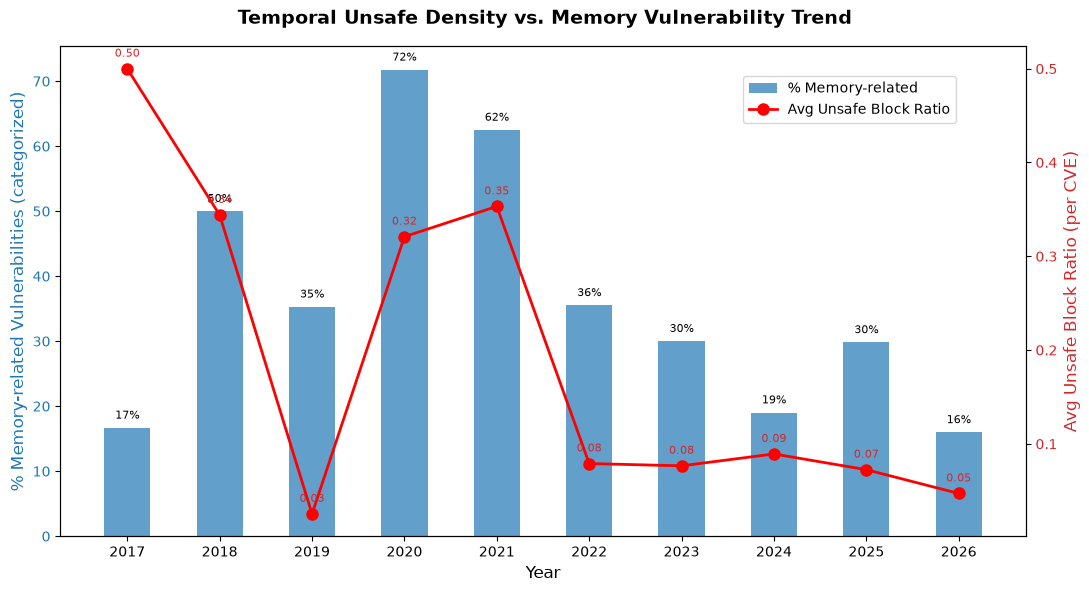

Figure saved to: fig/rq5/temporal_unsafe_vs_memory.png


In [5]:
fig, ax1 = plt.subplots(figsize=(11, 6))

x = range(len(df_year))
years = df_year['year'].astype(int).tolist()

# Bar chart: % memory-related
bars = ax1.bar(x, df_year['mem_related_pct'], width=0.5,
               label='% Memory-related', color='tab:blue', alpha=0.7)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('% Memory-related Vulnerabilities (categorized)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels(years)

# Line chart: avg unsafe block ratio
ax2 = ax1.twinx()
ax2.plot(x, df_year['avg_unsafe_block_ratio'], 'ro-',
         label='Avg Unsafe Block Ratio', markersize=8, linewidth=2)
ax2.set_ylabel('Avg Unsafe Block Ratio (per CVE)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Value labels on bars
for bar, val in zip(bars, df_year['mem_related_pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

# Value labels on line
for xi, val in zip(x, df_year['avg_unsafe_block_ratio']):
    ax2.text(xi, val + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=8, color='tab:red')

fig.suptitle('Temporal Unsafe Density vs. Memory Vulnerability Trend', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
fig.savefig('fig/rq5/temporal_unsafe_vs_memory.png', facecolor='white', dpi=200)
plt.show()
print("Figure saved to: fig/rq5/temporal_unsafe_vs_memory.png")